# 03 · Inference & Execution-Accuracy Evaluation

Generate SQL on BIRD dev with the fine-tuned adapter, then score with
execution accuracy (EX), valid-SQL rate and exact match — plus a baseline
(same model, no fine-tuning) for a clean before/after comparison.

**Self-sufficient:** runs in a *fresh* session — it pulls the fine-tuned
adapter from the **Hugging Face Hub** and rebuilds the dev set if needed. (If
you're in the same session as notebook 02, it reuses what's already there.)

In [17]:
# --- SETUP: run me first (works on Colab, Kaggle AND locally) ---
import os, sys, subprocess
if not os.path.exists('src') and os.path.basename(os.getcwd()) != 'text2sql-finetuning':
    if not os.path.isdir('text2sql-finetuning'):
        subprocess.run(['git', 'clone', 'https://github.com/Shiverion/text2sql-finetuning.git'], check=True)
    os.chdir('text2sql-finetuning')
sys.path.insert(0, os.getcwd())
print('working dir :', os.getcwd())
print('src present :', os.path.isdir('src'))

working dir : /kaggle/working/text2sql-finetuning
src present : True


In [18]:
!pip install -q unsloth   # needed for inference if this is a fresh session

## 1. Choose the fine-tuned model
Defaults to your HF adapter repo (works in any session). If you're in the same
session as notebook 02, you can point this at the local `outputs/...` folder.

In [19]:
FT_MODEL = 'Shiverion/qwen2.5-coder-1.5b-bird-qlora'   # <- your HF repo from notebook 02
# FT_MODEL = 'outputs/qwen2.5-coder-1.5b-bird-qlora'   # use this if same session as nb 02
BASE_MODEL = 'unsloth/Qwen2.5-Coder-1.5B-Instruct'
print('fine-tuned :', FT_MODEL)

fine-tuned : Shiverion/qwen2.5-coder-1.5b-bird-qlora


## 2. Prepare the dev set (idempotent)
Downloads + preprocesses BIRD dev only if `bird_dev.jsonl` isn't already here.
The real `.sqlite` databases are required to *execute* the predicted queries.

In [20]:
import os, glob
REPO = os.getcwd(); BIRD = 'https://bird-bench.oss-cn-beijing.aliyuncs.com'
dev_jsonl = 'data/processed/bird_dev.jsonl'
if os.path.exists(dev_jsonl) and os.path.getsize(dev_jsonl) > 0:
    print('dev set already prepared:', dev_jsonl)
else:
    if not glob.glob('dev*/dev.json'):
        print('downloading dev.zip (~330 MB)...', flush=True)
        !wget --progress=dot:giga -c {BIRD}/dev.zip -O /tmp/dev.zip
        !unzip -o -q /tmp/dev.zip -d {REPO}
        !rm -f /tmp/dev.zip
    for z in glob.glob('dev*/dev_databases.zip'):
        print('un-nesting', z, '...', flush=True)
        !unzip -o -q '{z}' -d '{os.path.dirname(z)}'
        !rm -f '{z}'
    dj = glob.glob('dev*/dev.json')[0]; dd = os.path.dirname(dj) + '/dev_databases'
    dt = os.path.dirname(dj) + '/dev_tables.json'   # same schema format as training
    !python -m src.data_prep --source bird --json {dj} --tables_json {dt} --db_root {dd} --out {dev_jsonl}
n = sum(1 for _ in open(dev_jsonl, encoding='utf-8'))
print(f'{dev_jsonl}: {n} records (must be > 0 for execution eval)')

dev set already prepared: data/processed/bird_dev.jsonl
data/processed/bird_dev.jsonl: 1534 records (must be > 0 for execution eval)


## 3. Baseline — base model, zero-shot
Establishes the lift attributable to fine-tuning. (`--limit 200` keeps it
quick; remove for the full dev set.)

In [21]:
!python -m src.inference --model_dir {BASE_MODEL} \
    --input data/processed/bird_dev.jsonl --output outputs/preds_base.jsonl --limit 200
!python -m src.evaluate --pred outputs/preds_base.jsonl --report outputs/metrics_base.json

[inference] 200 records from data/processed/bird_dev.jsonl
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100%|███████████████████████| 338/338 [00:00<00:00, 477.42it/s]
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/pytho

## 4. Fine-tuned model (from Hugging Face)
`src.inference` loads the adapter and its base model automatically (Unsloth
reads `base_model_name_or_path` from the adapter config).

In [22]:
!python -m src.inference --model_dir {FT_MODEL} \
    --input data/processed/bird_dev.jsonl --output outputs/preds_ft.jsonl --limit 200
!python -m src.evaluate --pred outputs/preds_ft.jsonl --report outputs/metrics_ft.json

[inference] 200 records from data/processed/bird_dev.jsonl
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100%|███████████████████████| 338/338 [00:00<00:00, 476.75it/s]
adapter_model.safetensors: 100%|███████████| 73.9M/73.9M [00:05<00:00, 13.6MB/s]
Unsloth 2026.6.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take p

## 5. Compare

                   baseline fine-tuned
execution_accuracy     0.14      0.155
valid_sql_rate          0.4      0.735
exact_match             0.0       0.02


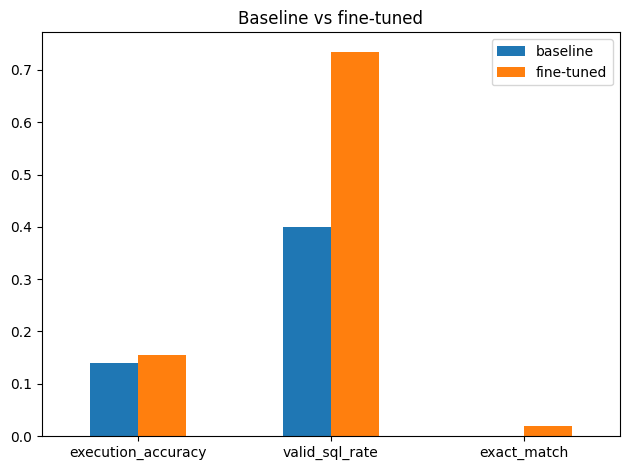

In [23]:
import json, pandas as pd, os
os.makedirs('report/figures', exist_ok=True)
base = json.load(open('outputs/metrics_base.json'))
ft   = json.load(open('outputs/metrics_ft.json'))
tbl = pd.DataFrame({'baseline': base, 'fine-tuned': ft}).loc[
    ['execution_accuracy','valid_sql_rate','exact_match']]
print(tbl)
ax = tbl.plot(kind='bar', rot=0, title='Baseline vs fine-tuned'); ax.figure.tight_layout()
ax.figure.savefig('report/figures/before_after.png', dpi=120)

## 6. Error analysis
Read the captured failures to find systematic mistakes (hallucinated columns,
wrong joins, missing GROUP BY). This is what drives the next experiment.

In [24]:
for e in ft.get('error_samples', [])[:10]:
    print(e['type'])
    print('  pred:', e.get('pred',''))
    if 'error' in e: print('  err :', e['error'])
    print()

wrong_result
  pred: SELECT MAX(T1.`Free Meal Count (K-12)`) / T1.`Enrollment (K-12)` FROM frpm AS T1 INNER JOIN schools AS T2 ON T1.CDSCode = T2.CDSCode WHERE T2.County = 'Alameda'

wrong_result
  pred: SELECT T2.`Free Meal Count (Ages 5-17)` / T2.`Enrollment (Ages 5-17)` FROM schools AS T1 INNER JOIN frpm AS T2 ON T1.CDSCode = T2.CDSCode WHERE T1.StatusType = 'Continuation' ORDER BY T2.`Free Meal Count (Ages 5-17)` / T2.`Enrollment (Ages 5-17)` LIMIT 3

wrong_result
  pred: SELECT T2.Zip FROM frpm AS T1 INNER JOIN schools AS T2 ON T1.CDSCode = T2.CDSCode WHERE T1.`Charter School (Y/N)` = 1 AND T2.County = 'Fresno County Office of Education'

exec_error
  pred: SELECT T2.MailingStreet FROM frpm AS T1 INNER JOIN schools AS T2 ON T1.CDSCode = T2.CDSCode WHERE T1.`FRPM Count (K-12)` = ( SELECT MAX(`FRPM Count (K-12)`) FROM frpm )
  err : no such column: T2.MailingStreet

wrong_result
  pred: SELECT T1.Phone FROM schools AS T1 INNER JOIN frpm AS T2 ON T1.CDSCode = T2.CDSCode WHERE T2.`Cha

## 7. Try the motivating question live
Uses the bundled fintech DB, so it works even without BIRD downloaded.

In [25]:
from src.inference import load_model, generate_batch
from src.prompts import build_messages, extract_sql
from src.schema_utils import serialize_schema
model, tok, _ = load_model(FT_MODEL, 2048, load_in_4bit=True)
tok.padding_side='left'; tok.pad_token = tok.pad_token or tok.eos_token
schema = serialize_schema('data/sample/db/fintech/fintech.sqlite')
q = 'Who were the top performing merchants last quarter?'
prompt = tok.apply_chat_template(build_messages(schema, q), tokenize=False, add_generation_prompt=True)
print(extract_sql(generate_batch(model, tok, [prompt], 256)[0]))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Unsloth 2026.6.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking

SELECT T1.name FROM merchants AS T1 INNER JOIN transactions AS T2 ON T1.merchant_id = T2.merchant_id WHERE T2.txn_date LIKE '%-03%' ORDER BY T2.amount DESC LIMIT 5
